# Gradient Boosting Regressor

Evaluate the custom NumPy-based 'GradientBoostingRegressor' on California Housing and compare it with sklearn.

**Goals**
- Train the custom implementation.
- Evaluate MSE, RMSE, MAE, and R².
- Inspect residuals.
- Benchmark against sklearn.
- Interpret the results.

> This is a simplified educational Gradient Boosting implementation, not a full XGBoost/LightGBM implementation.

In [4]:
import time
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor as SklearnGradientBoostingRegressor

from ml_from_scratch.trees.boosting import GradientBoostingRegressor
from ml_from_scratch.metrics.regression import (
    mean_squared_error,
    root_mean_squared_error,
    mean_abs_error,
    r2_score,
)

## 1. Problem Definition

Predict the median house value for a California district from demographic and geographical features.

This is a supervised regression problem because the target is continuous.

In [7]:
housing = fetch_california_housing(as_frame = True)

X = housing.data
y = housing.target

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X.head()

X shape: (20640, 8)
y shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
print('Features:')
print(X.columns.tolist())

print('\nTarget statistics:')
print(y.describe())

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target statistics:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


## 2. Train / Test Split

We keep 20% of the data as a held-out test set.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 22)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 16512
Test samples: 4128


## 3. Train Custom Gradient Boosting

Configuration:
- n_estimators = 50
- learning_rate = 0.05
- max_depth = 3
- min_samples_split = 2

In [10]:
custom_model = GradientBoostingRegressor(n_estimators = 50, learning_rate = 0.05, max_depth = 3, min_samples_split = 2)

start_time = time.perf_counter()

custom_model.fit(X_train.to_numpy(), y_train.to_numpy())

custom_training_time = time.perf_counter() - start_time

custom_predictions = custom_model.predict(X_test.to_numpy())

print(f'Custom training time: {custom_training_time:.6f} seconds')

Custom training time: 1944.199088 seconds


In [11]:
custom_mse = mean_squared_error(y_test.to_numpy(), custom_predictions)
custom_rmse = root_mean_squared_error(y_test.to_numpy(), custom_predictions)
custom_mae = mean_abs_error(y_test.to_numpy(), custom_predictions)
custom_r2 = r2_score(y_test.to_numpy(), custom_predictions)

custom_results = {
    'MSE': custom_mse,
    'RMSE': custom_rmse,
    'MAE': custom_mae,
    'R2': custom_r2,
}

pd.Series(custom_results)

MSE     0.417057
RMSE    0.645799
MAE     0.481672
R2      0.679052
dtype: float64

## 4. Error Analysis

In [12]:
residuals = y_test.to_numpy() - custom_predictions

print('Residual mean:', np.mean(residuals))
print('Residual std:', np.std(residuals))
print('Maximum absolute error:', np.max(np.abs(residuals)))

Residual mean: -0.005406689368450927
Residual std: 0.6457767711283572
Maximum absolute error: 3.4797912202434844


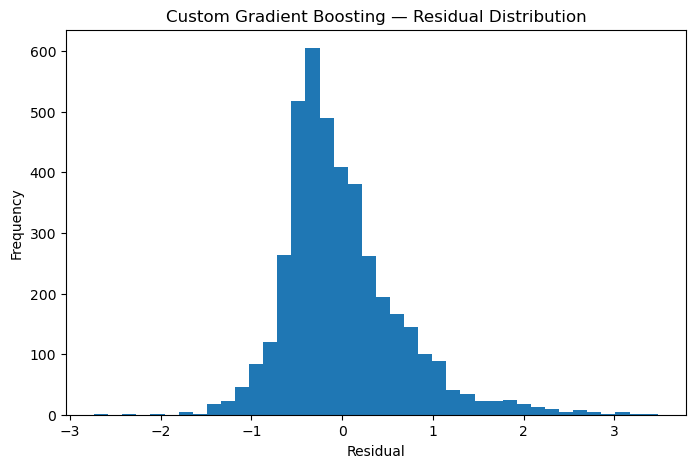

In [13]:
plt.figure(figsize = (8, 5))
plt.hist(residuals, bins = 40)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Custom Gradient Boosting — Residual Distribution')
plt.show()

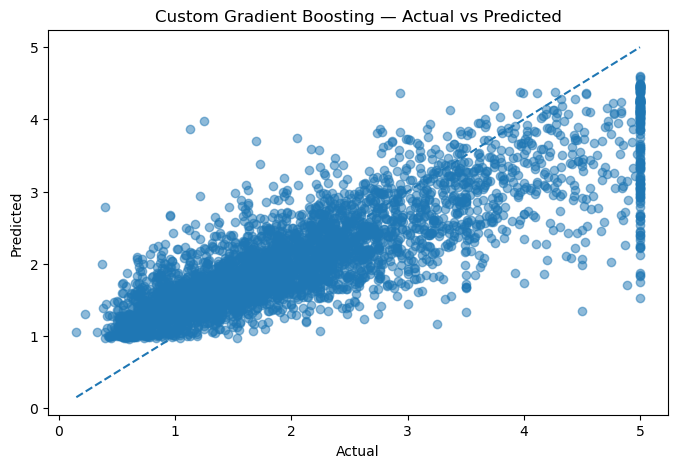

In [14]:
plt.figure(figsize = (8, 5))
plt.scatter(y_test.to_numpy(), custom_predictions, alpha = 0.5)

min_value = min(y_test.min(), custom_predictions.min())
max_value = max(y_test.max(), custom_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle = '--'
)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Custom Gradient Boosting — Actual vs Predicted')
plt.show()

## 5. sklearn Reference Model

Use the same main hyperparameters. The sklearn model is a reference for validating the custom implementation; exact predictions are not expected to match.

In [15]:
sklearn_model = SklearnGradientBoostingRegressor(n_estimators = 50, learning_rate = 0.05, max_depth = 3, min_samples_split = 2, random_state = 22)

start_time = time.perf_counter()

sklearn_model.fit(X_train, y_train)

sklearn_training_time = time.perf_counter() - start_time
sklearn_predictions = sklearn_model.predict(X_test)

print(f'sklearn training time: {sklearn_training_time:.6f} seconds')

sklearn training time: 2.100987 seconds


In [17]:
sklearn_mse = mean_squared_error(y_test.to_numpy(), sklearn_predictions)
sklearn_rmse = root_mean_squared_error(y_test.to_numpy(), sklearn_predictions)
sklearn_mae = mean_abs_error(y_test.to_numpy(), sklearn_predictions)
sklearn_r2 = r2_score(y_test.to_numpy(), sklearn_predictions)

sklearn_results = {
    'MSE': sklearn_mse,
    'RMSE': sklearn_rmse,
    'MAE': sklearn_mae,
    'R2': sklearn_r2,
}

pd.Series(sklearn_results)

MSE     0.417107
RMSE    0.645838
MAE     0.481685
R2      0.679014
dtype: float64

## 6. Benchmark Comparison

In [19]:
comparison = pd.DataFrame(
    {
        'My Gradient Boosting': [
            custom_training_time,
            custom_mse,
            custom_rmse,
            custom_mae,
            custom_r2,
        ],
        'sklearn Gradient Boosting': [
            sklearn_training_time,
            sklearn_mse,
            sklearn_rmse,
            sklearn_mae,
            sklearn_r2,
        ],
    },
    index=[
        'Training Time (seconds)',
        'MSE',
        'RMSE',
        'MAE',
        'R2',
    ]
)

comparison

,My Gradient Boosting,sklearn Gradient Boosting
Training Time (seconds),1944.199088,2.100987
MSE,0.417057,0.417107
RMSE,0.645799,0.645838
MAE,0.481672,0.481685
R2,0.679052,0.679014


## 7. Prediction Difference

In [20]:
prediction_difference = np.mean(np.abs(custom_predictions - sklearn_predictions))

print(f'Mean absolute prediction difference: {prediction_difference:.6f}')

Mean absolute prediction difference: 0.000202


## 8. Final Interpretation

The custom Gradient Boosting Regressor was evaluated on the held-out California Housing test set using MSE, RMSE, MAE, and R².

The experiment demonstrates the core boosting workflow: start with the target mean, calculate residuals, fit a regression tree to the residuals, update the current predictions using the learning rate, and repeat this process for multiple estimators.

The sklearn implementation serves as a reference point. Differences in predictive performance and training time are expected because the custom implementation is educational and uses different internal tree-building details.

The goal of this experiment is to validate the core algorithm on a real dataset rather than reproduce sklearn's exact predictions or production-level efficiency.

Gradient Boosting also demonstrates how multiple shallow trees can be combined sequentially to improve predictive performance.